# Generalized Additive Models

## What is a Generalized Additive Model?

Linear regression fits a straight line (or flat plane) through the data. That works well when the relationship between your predictors and your outcome is truly linear, but often it isn't. Maybe fuel efficiency drops steeply at first as engine size increases, then levels off. Maybe the relationship between age and income curves upward through mid-career then flattens. A straight line would miss all of that.

One option is polynomial regression — adding squared and cubed terms. But that can get unwieldy, and high-degree polynomials tend to produce wild behavior at the edges of the data.

**Generalized Additive Models (GAMs)** offer a more elegant solution. Instead of fitting one equation to the whole dataset, a GAM fits a **separate smooth curve** for each predictor, then adds those curves together.

So each predictor gets to have its own flexible, non-linear relationship with the outcome, and the final prediction is the sum of all those individual relationships.

### The additive part

The "additive" in GAM is important. The model's prediction is built by adding up independent contributions from each predictor:

    prediction = baseline + f(predictor_1) + f(predictor_2) + ... + f(predictor_p)

Each `f()` is a smooth curve fitted to that particular predictor. You can plot each one separately and see exactly how that variable affects the outcome, all else being equal.

This is different from a black-box model like a neural network, where you can't easily inspect the contribution of individual variables.

### The tradeoff compared to linear regression

- **More flexible than linear regression**: each predictor's curve can bend and curve to fit the data, rather than being constrained to a straight line.
- **More interpretable than fully non-parametric models**: you can still look at each predictor's contribution independently.
- **Limitation**: the model assumes the predictors' effects *add up* independently. If two predictors interact — if the effect of one depends on the level of the other — a GAM won't capture that unless you explicitly add interaction terms.

### When to use GAMs

GAMs are a good choice when:
- You suspect the relationship between predictors and outcome is non-linear.
- You want to understand the shape of each predictor's effect (not just a single coefficient).
- You need predictions that are better than linear regression but still want interpretability.
- You're trying to understand your data rather than just optimizing prediction accuracy.

## Setup: How we'll demonstrate GAMs

The most popular Python library for GAMs is `pygam`, but it requires a separate installation. Instead, we'll build a GAM from scratch using `sklearn`'s `SplineTransformer`, which implements the core idea directly.

A **spline** is a piecewise smooth curve — think of it as a flexible ruler that bends to fit the data. Instead of fitting one global polynomial, a spline fits different low-degree polynomials in different regions of the predictor space, joined smoothly at points called **knots**.

`SplineTransformer` transforms each predictor into a set of spline basis functions. When we then fit a linear regression on those transformed features, the result is a smooth non-linear curve in the original predictor space — exactly what a GAM does per predictor.

By applying this to each predictor separately and combining the predictions, we get a proper GAM.

In [1]:
# This shows the output of every line in a cell, not just the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import ipywidgets as widgets
from ipywidgets import interact

plt.rc('figure', figsize=(14, 5))
np.set_printoptions(precision=4, suppress=True)

## Load Data

We'll use the diabetes dataset from sklearn, which is a classic regression benchmark. It contains 10 predictors for 442 patients (age, sex, BMI, blood pressure, and six blood serum measurements), and the outcome is a measure of disease progression one year after baseline.

We'll focus on a few predictors to keep the visualizations manageable.

In [3]:
# Load the diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


Text(0.5, 0, 'BMI')

Text(0, 0.5, 'Disease Progression')

Text(0.5, 1.0, 'Target vs BMI')

Text(0.5, 0, 'Blood Pressure')

Text(0, 0.5, 'Disease Progression')

...

Text(0, 0.5, 'Disease Progression')

Text(0.5, 1.0, 'Target vs Serum Triglycerides (log)')

Text(0.5, 0, 'Age')

Text(0, 0.5, 'Disease Progression')

Text(0.5, 1.0, 'Target vs Age')

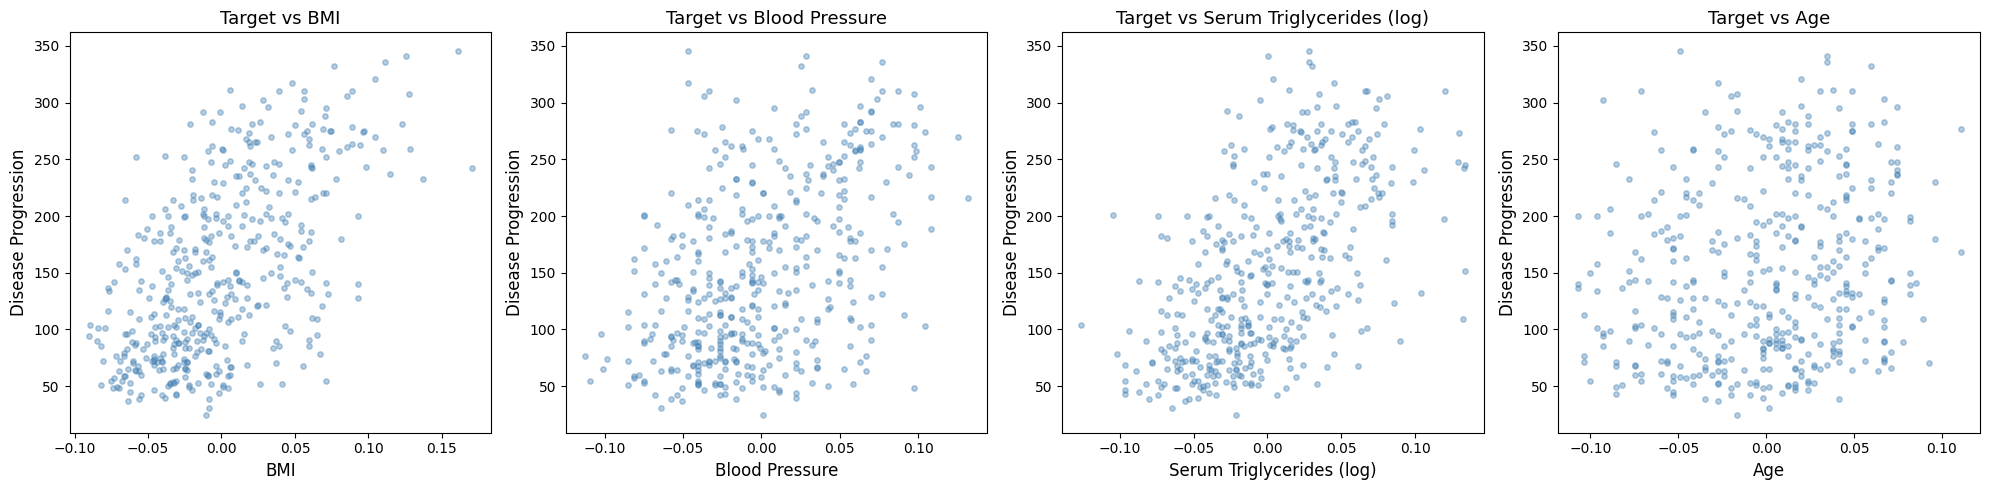

In [5]:
# Visualize the relationships between key predictors and the outcome
focus_predictors = ['bmi', 'bp', 's5', 'age']
feature_labels = {'bmi': 'BMI', 'bp': 'Blood Pressure', 's5': 'Serum Triglycerides (log)', 'age': 'Age'}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, focus_predictors):
    ax.scatter(df[col], df['target'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feature_labels[col], fontsize=12)
    ax.set_ylabel('Disease Progression', fontsize=12)
    ax.set_title(f'Target vs {feature_labels[col]}', fontsize=13)
plt.tight_layout()
plt.show()

Some of these relationships look curved or uneven — BMI and blood pressure have a general upward trend, but it's not perfectly linear. This is exactly where a GAM can add value over a simple linear regression.

## What splines look like

Before fitting a full GAM, let's see what a spline transformation actually does to a single predictor.

A spline with `n_knots` knots divides the predictor range into segments. Within each segment, it fits a smooth polynomial. These segment polynomials are forced to join smoothly at the knot boundaries, so the overall curve looks like a single smooth function even though it's piecewise.

More knots = more flexibility to fit complex curves. Fewer knots = smoother, more conservative fit.

Pipeline(steps=[('splinetransformer',
                 SplineTransformer(include_bias=False, n_knots=3)),
                ('ridge', Ridge(alpha=0.01))])

Text(0.5, 0, 'BMI')

Text(0, 0.5, 'Disease Progression')

Text(0.5, 1.0, 'Spline fit: 3 knots')

Pipeline(steps=[('splinetransformer',
                 SplineTransformer(include_bias=False, n_knots=6)),
                ('ridge', Ridge(alpha=0.01))])

...

Pipeline(steps=[('splinetransformer',
                 SplineTransformer(include_bias=False, n_knots=12)),
                ('ridge', Ridge(alpha=0.01))])

Text(0.5, 0, 'BMI')

Text(0, 0.5, 'Disease Progression')

Text(0.5, 1.0, 'Spline fit: 12 knots')

Text(0.5, 1.02, 'Spline flexibility increases with more knots')

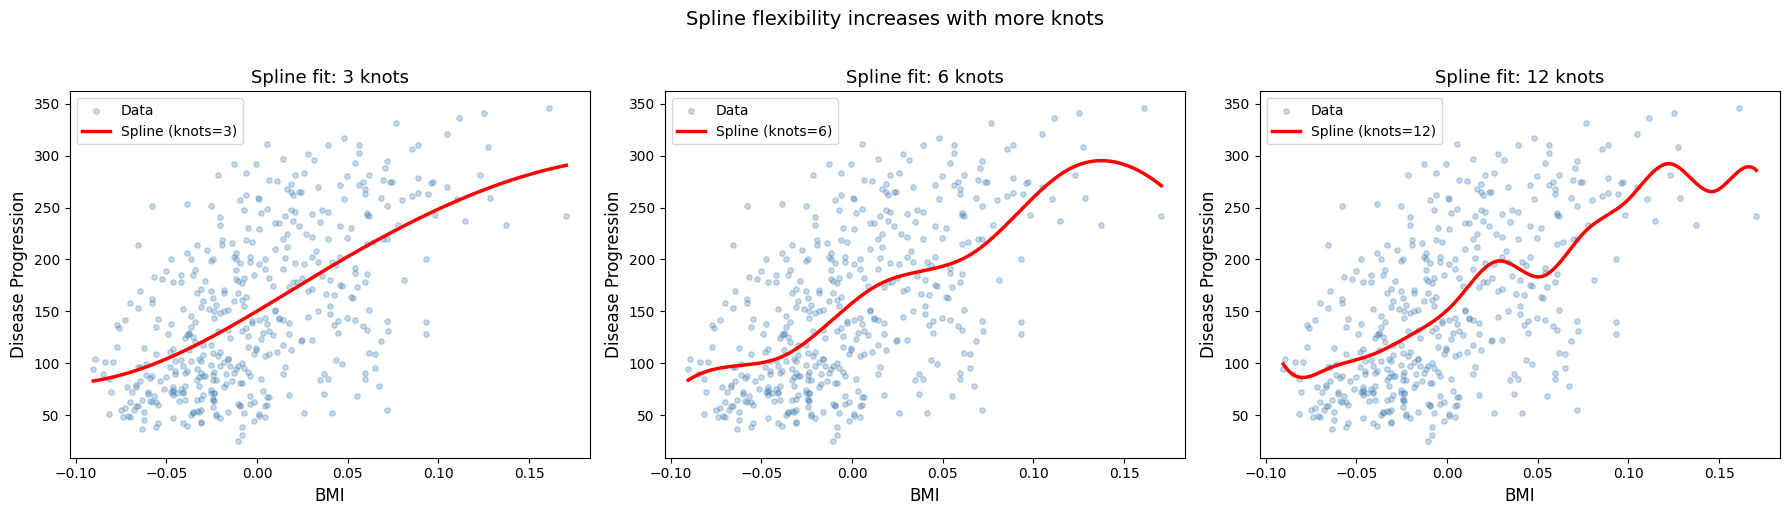

In [6]:
# Show the spline fit for BMI vs disease progression with different numbers of knots
X_bmi = df[['bmi']].values
y = df['target'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_range = np.linspace(X_bmi.min(), X_bmi.max(), 300).reshape(-1, 1)

for ax, n_knots in zip(axes, [3, 6, 12]):
    pipe = make_pipeline(
        SplineTransformer(n_knots=n_knots, degree=3, include_bias=False),
        Ridge(alpha=0.01)
    )
    pipe.fit(X_bmi, y)
    y_pred = pipe.predict(x_range)

    ax.scatter(X_bmi, y, alpha=0.3, s=15, color='steelblue', label='Data')
    ax.plot(x_range, y_pred, color='red', linewidth=2.5, label=f'Spline (knots={n_knots})')
    ax.set_xlabel('BMI', fontsize=12)
    ax.set_ylabel('Disease Progression', fontsize=12)
    ax.set_title(f'Spline fit: {n_knots} knots', fontsize=13)
    ax.legend()

plt.suptitle('Spline flexibility increases with more knots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

With 3 knots the spline is smooth and fairly conservative. With 12 knots it starts chasing individual data points — this is the overfitting risk with too many knots. Choosing the right number of knots is the main tuning decision in a GAM.

## Fitting a GAM

We'll build a GAM by applying a separate `SplineTransformer` to each predictor, concatenating the resulting features, and fitting a single linear regression. This is mathematically equivalent to the standard GAM formulation.

We'll use four predictors: BMI, blood pressure, a serum triglyceride measure, and age.

In [7]:
from sklearn.compose import ColumnTransformer

X = df[focus_predictors].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_knots = 6  # reasonable default

# Build the GAM: apply SplineTransformer to each column separately, then fit linear regression
col_transformer = ColumnTransformer(
    [(f'spline_{col}', SplineTransformer(n_knots=n_knots, degree=3, include_bias=False), [i])
     for i, col in enumerate(focus_predictors)]
)

gam_model = Pipeline([
    ('splines', col_transformer),
    ('regression', Ridge(alpha=1.0))
])

gam_model.fit(X_train, y_train)

y_pred_gam = gam_model.predict(X_test)
r2_gam = r2_score(y_test, y_pred_gam)
print(f'GAM Test R²: {r2_gam:.4f}')

Pipeline(steps=[('splines',
                 ColumnTransformer(transformers=[('spline_bmi',
                                                  SplineTransformer(include_bias=False,
                                                                    n_knots=6),
                                                  [0]),
                                                 ('spline_bp',
                                                  SplineTransformer(include_bias=False,
                                                                    n_knots=6),
                                                  [1]),
                                                 ('spline_s5',
                                                  SplineTransformer(include_bias=False,
                                                                    n_knots=6),
                                                  [2]),
                                                 ('spline_age',
                                                  SplineTransformer(include_bias=False,
                                                                    n_knots=6),
                                                  [3])])),
                ('regression', Ridge())])

GAM Test R²: 0.5103


## Comparison: Linear Regression vs GAM

Now let's compare the GAM against a standard multiple linear regression using the same four predictors on the same train/test split. This shows directly whether allowing non-linear smooth curves per predictor improves things.

In [8]:
# Fit a standard linear regression for comparison
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)

print(f'Linear Regression Test R²: {r2_linear:.4f}')
print(f'GAM Test R²:                {r2_gam:.4f}')
print(f'Improvement from GAM:       {r2_gam - r2_linear:+.4f}')

LinearRegression()

Linear Regression Test R²: 0.4569
GAM Test R²:                0.5103
Improvement from GAM:       +0.0534


Text(0.5, 0, 'Actual Disease Progression')

Text(0, 0.5, 'Predicted Disease Progression')

Text(0.5, 1.0, 'Linear Regression\nTest R² = 0.4569')

Text(0.5, 0, 'Actual Disease Progression')

Text(0, 0.5, 'Predicted Disease Progression')

Text(0.5, 1.0, 'GAM (Splines)\nTest R² = 0.5103')

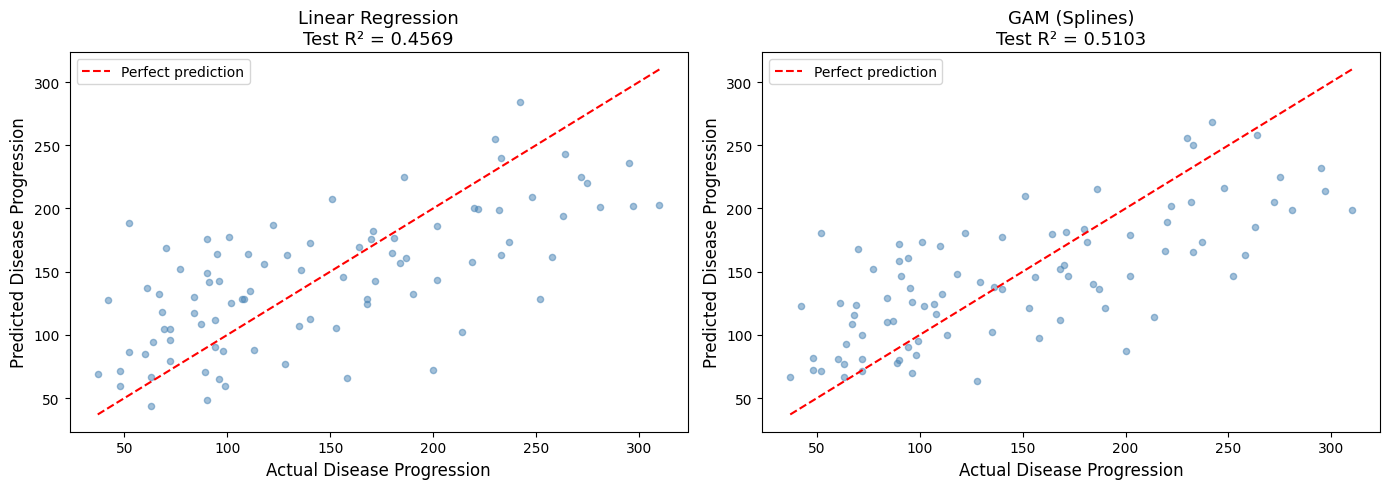

In [9]:
# Visual comparison: actual vs predicted for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title, r2 in [
    (axes[0], y_pred_linear, 'Linear Regression', r2_linear),
    (axes[1], y_pred_gam, 'GAM (Splines)', r2_gam)
]:
    ax.scatter(y_test, preds, alpha=0.5, s=20, color='steelblue')
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Disease Progression', fontsize=12)
    ax.set_ylabel('Predicted Disease Progression', fontsize=12)
    ax.set_title(f'{title}\nTest R² = {r2:.4f}', fontsize=13)
    ax.legend()

plt.tight_layout()
plt.show()

Points that land exactly on the red dashed line are perfect predictions. Points scattered around it show prediction error. If the GAM's points cluster closer to the line than the linear model's, the non-linear flexibility is paying off.

## Interpreting the GAM: partial effect plots

One of the great advantages of GAMs over black-box models is interpretability. We can plot the **partial effect** of each predictor — the smooth curve that represents how the outcome changes as that predictor varies, holding all others at their average.

This is the GAM equivalent of a linear regression coefficient, but much richer: instead of a single number, we get the full shape of the relationship.

Text(0.5, 0, 'BMI')

Text(0, 0.5, 'Partial effect on outcome')

Text(0.5, 1.0, 'Partial effect of BMI')

Text(0.5, 0, 'Blood Pressure')

Text(0, 0.5, 'Partial effect on outcome')

...

Text(0.5, 1.0, 'Partial effect of Serum Triglycerides (log)')

Text(0.5, 0, 'Age')

Text(0, 0.5, 'Partial effect on outcome')

Text(0.5, 1.0, 'Partial effect of Age')

Text(0.5, 1.02, "GAM Partial Effect Plots (each curve shows one predictor's contribution)")

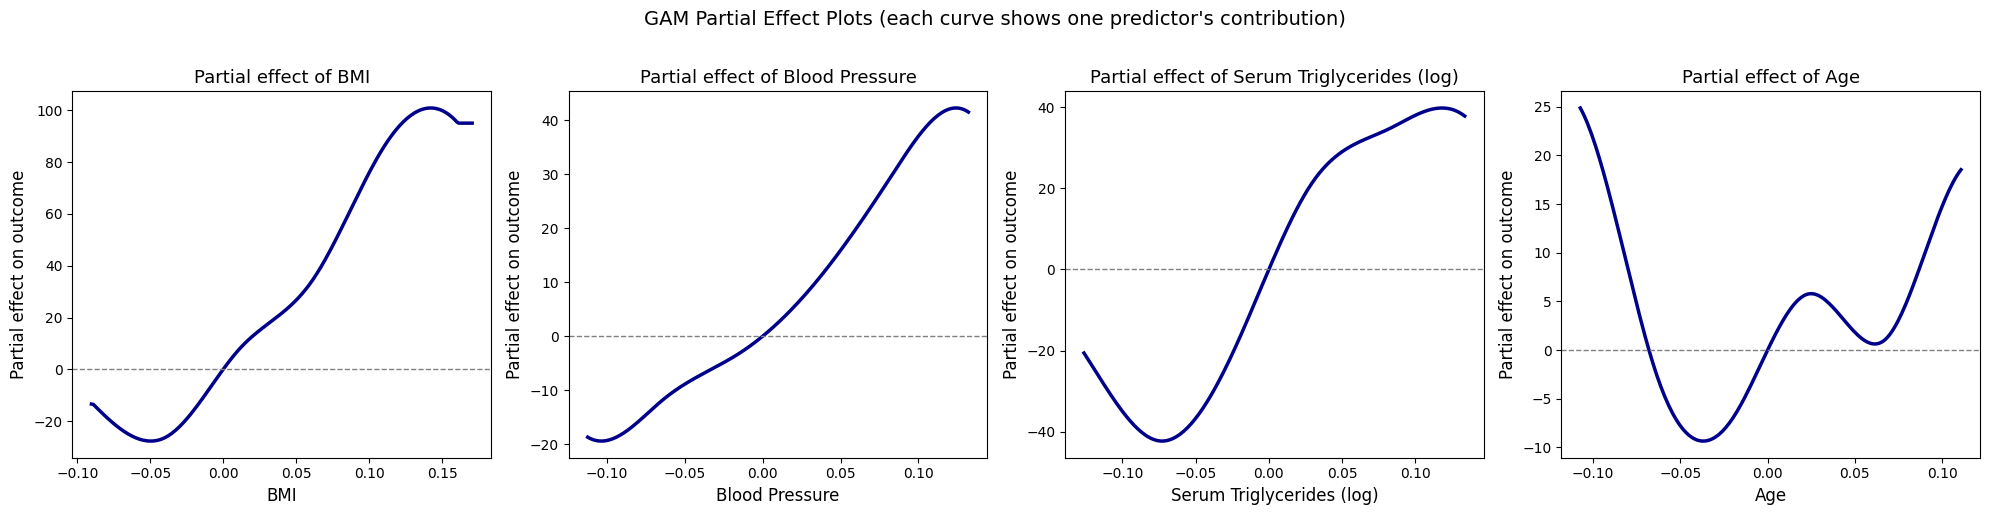

In [10]:
# Plot partial effects for each predictor
# Hold all other predictors at their mean, vary one at a time
X_full = df[focus_predictors].values
X_means = X_full.mean(axis=0)

fig, axes = plt.subplots(1, len(focus_predictors), figsize=(20, 5))

for i, (ax, col) in enumerate(zip(axes, focus_predictors)):
    x_range = np.linspace(X_full[:, i].min(), X_full[:, i].max(), 200)

    # Build test grid: vary predictor i, hold others at mean
    X_grid = np.tile(X_means, (200, 1))
    X_grid[:, i] = x_range

    y_pred_full = gam_model.predict(X_grid)

    # Baseline: all predictors at their mean
    X_baseline = X_means.reshape(1, -1)
    y_baseline = gam_model.predict(X_baseline)[0]

    # Partial effect = deviation from baseline
    partial_effect = y_pred_full - y_baseline

    ax.plot(x_range, partial_effect, color='darkblue', linewidth=2.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(feature_labels[col], fontsize=12)
    ax.set_ylabel('Partial effect on outcome', fontsize=12)
    ax.set_title(f'Partial effect of {feature_labels[col]}', fontsize=13)

plt.suptitle('GAM Partial Effect Plots (each curve shows one predictor\'s contribution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Each curve shows how much that predictor alone contributes to the prediction, relative to an average patient. A curve that's higher on the right means the predictor has a positive effect at high values; one that curves and then flattens shows a diminishing relationship. This is the interpretability advantage of GAMs over methods like random forests or neural networks.

## Interactive: tuning the number of knots

The number of knots controls how flexible each predictor's smooth curve is. Too few knots and the model underfits — it misses real patterns. Too many and it overfits — it chases noise in the training data and generalizes poorly.

Use the slider below to explore how changing the number of knots affects the model's fit and test performance. Watch the partial effect plots change shape, and watch the test R² rise and then fall as you increase the knots too much.

In [11]:
@interact(
    n_knots=widgets.IntSlider(min=3, max=20, step=1, value=6, description='Knots per predictor')
)
def interactive_gam(n_knots):
    col_transformer_i = ColumnTransformer(
        [(f'spline_{col}', SplineTransformer(n_knots=n_knots, degree=3, include_bias=False), [i])
         for i, col in enumerate(focus_predictors)]
    )
    model_i = Pipeline([
        ('splines', col_transformer_i),
        ('regression', Ridge(alpha=1.0))
    ])
    model_i.fit(X_train, y_train)

    r2_train = r2_score(y_train, model_i.predict(X_train))
    r2_test = r2_score(y_test, model_i.predict(X_test))
    print(f'Training R²: {r2_train:.4f}   Test R²: {r2_test:.4f}')

    fig, axes = plt.subplots(1, len(focus_predictors), figsize=(20, 5))
    for i, (ax, col) in enumerate(zip(axes, focus_predictors)):
        x_range = np.linspace(X_full[:, i].min(), X_full[:, i].max(), 200)
        X_grid = np.tile(X_means, (200, 1))
        X_grid[:, i] = x_range
        y_pred_grid = model_i.predict(X_grid)
        y_base = model_i.predict(X_means.reshape(1, -1))[0]
        partial = y_pred_grid - y_base

        ax.plot(x_range, partial, color='darkblue', linewidth=2.5)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_xlabel(feature_labels[col], fontsize=11)
        ax.set_ylabel('Partial effect', fontsize=11)
        ax.set_title(f'{feature_labels[col]}', fontsize=12)

    plt.suptitle(f'GAM Partial Effects with {n_knots} knots per predictor', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=6, description='Knots per predictor', max=20, min=3), Output()), _dom_cl…

## Summary

Generalized Additive Models occupy a useful middle ground in the flexibility-interpretability tradeoff:

| Model | Flexibility | Interpretability |
|---|---|---|
| Linear Regression | Low — straight lines only | High — one coefficient per predictor |
| **GAM** | **Medium — smooth curves per predictor** | **High — can plot each predictor's effect** |
| Neural Network | Very high | Low — difficult to inspect individual effects |

Key things to remember:

- GAMs fit a separate smooth curve for each predictor and add them up. No single global line, no black box.
- You can visualize exactly how each predictor affects the outcome — this is valuable for understanding and communicating your model.
- The main tuning parameter is the number of knots per predictor. More knots = more flexibility = more overfitting risk.
- GAMs assume predictor effects are additive and independent. If two predictors interact strongly, you'll need to add explicit interaction terms.
- For production use, consider the `pygam` library (`pip install pygam`), which provides a full-featured GAM implementation with built-in smoothing parameter selection.